# Backpropagation Neural Network (BPN) - Heart Disease Dataset

In this notebook, a Backpropagation Neural Network (BPN) is implemented for the Heart Disease Cleveland dataset.

According to the lecture slides, a BPN is a feedforward neural network with hidden layer(s) and an error back-propagation learning algorithm.

The main goals of this notebook are:
- to train a BPN model on the Heart Disease dataset
- to evaluate learning and recalling performance
- to test different hidden-layer nodes
- to test different learning rates
- to compare the results using classification metrics

## 1. Import Required Libraries

This section imports the libraries needed for:
- loading the preprocessed data
- building the neural network model
- evaluating performance
- visualizing the results

In [27]:
# Import pandas for loading CSV files
import pandas as pd

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import the neural network model
from sklearn.neural_network import MLPClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Load the Preprocessed Data

The BPN model requires scaled input features.

For this reason, the scaled training and testing sets generated in the preprocessing notebook are loaded here.

The target labels are not scaled because this is a classification problem.

In [ ]:
# Load the scaled training features
X_train_scaled = pd.read_csv("../Preprocessing/X_train_scaled.csv")

# Load the scaled testing features
X_test_scaled = pd.read_csv("../Preprocessing/X_test_scaled.csv")

# Load the training labels
y_train = pd.read_csv("../Preprocessing/y_train.csv").squeeze()

# Load the testing labels
y_test = pd.read_csv("../Preprocessing/y_test.csv").squeeze()

# Check the shapes of the datasets
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



X_train_scaled shape: (212, 18)
X_test_scaled shape: (91, 18)
y_train shape: (212,)
y_test shape: (91,)


## 3. BPN Model Introduction

Based on the lecture slides, a Backpropagation Neural Network has:

- an input layer
- one or more hidden layers
- an output layer

The hidden layer uses a nonlinear transfer function, and the network updates its weights by minimizing the prediction error through backpropagation.

In this implementation, `MLPClassifier` from sklearn is used to represent a feedforward neural network trained with backpropagation.

## 4. Define the Base BPN Model

The first model is defined using one hidden layer.

Main parameters:
- `hidden_layer_sizes=(10,)` means one hidden layer with 10 nodes
- `activation='logistic'` uses the sigmoid function, which is consistent with the lecture slides
- `learning_rate_init=0.01` controls how fast the network updates weights
- `max_iter=1000` sets the stopping condition by maximum number of iterations
- `tol=1e-4` defines the tolerance for stopping when improvement becomes very small

This corresponds to the lecture discussion about:
- hidden-layer nodes
- hidden layers
- learning rate
- stop criterion 

In [29]:
# Create the baseline BPN model
bpn = MLPClassifier(
    hidden_layer_sizes=(10,),   # One hidden layer with 10 nodes
    activation='logistic',      # Sigmoid activation function
    learning_rate_init=0.01,    # Initial learning rate. how fast the model updates its weights during learning.
    max_iter=1000,              # Maximum number of iterations
    tol=1e-4,                   # Tolerance for stopping
    random_state=42             # Reproducibility
)

## 5. Learning Process

According to the lecture slides, the learning process involves:
- setting network parameters
- initializing weights and biases
- performing forward propagation
- computing the error
- backpropagating the error
- updating the weights repeatedly until the stop criterion is met

In sklearn, these steps are handled internally by `fit()`.

Therefore, calling `fit()` represents the learning stage of the BPN.

In [30]:
# Train the BPN model using the scaled training data & the target labels, meaning whether the patient has heart disease or not.
bpn.fit(X_train_scaled, y_train) 

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


this learning stage includes forward propagation, error calculation, backpropagation, and weight updates until the prediction error becomes the smaller target. In sklearn, all of that happens inside fit().

This is the step where the model learns which combinations of patient features are associated with heart disease. In practical terms, the model is trying to recognize hidden medical patterns that may not be obvious from looking at a single variable alone.

## 6. Recalling Process

The lecture slides describe recalling as the process of using the trained network to determine output values from new input values.

In sklearn, this recalling stage is represented by `predict()`.

The trained BPN is now used to make predictions on the testing set.

In [31]:
# Predict the labels of the testing set
y_pred_bpn = bpn.predict(X_test_scaled)

bpn.predict(...) uses the trained network to make predictions.

X_test_scaled is the unseen testing data.

y_pred_bpn stores the predicted class for each patient in the test set.

The model is no longer learning. It is now using what it learned during training to classify new patients to the heart disease class or the non-heart disease class.

This is the most clinically relevant stage, because it simulates real use. A hospital would not care how well the model memorizes training cases. What matters is whether it can correctly classify new patients it has never seen before.

## 7. Training and Testing Accuracy

To evaluate the BPN model, both training accuracy and testing accuracy are reported.

- Training accuracy shows how well the model learned the training samples
- Testing accuracy shows how well the model generalizes to unseen data

This matches the evaluation idea in the lecture slides, where the dataset is divided into training and testing groups. 

In [ ]:
# Calculate training accuracy on the training set.
train_acc_bpn = bpn.score(X_train_scaled, y_train)

# Calculate testing accuracy on the testing set.
test_acc_bpn = bpn.score(X_test_scaled, y_test)

# Print the results
print("BPN Training Accuracy:", train_acc_bpn)
print("BPN Testing Accuracy:", test_acc_bpn)

BPN Training Accuracy: 0.9905660377358491
BPN Testing Accuracy: 0.7802197802197802


NameError: name 'df' is not defined

The training accuracy is very high, almost 99%. This means the model learned the training examples extremely well.

The testing accuracy is much lower, around 78%. This means the model does not perform as well on unseen patients.

This gap suggests overfitting. The model fits the training data too closely, but generalizes less effectively to new cases.

In healthcare, testing accuracy is more important than training accuracy. A model that performs well only on training data is risky, because it may fail when used with real new patients. In medical decision support, we need a model that generalizes well, not one that only memorizes past records.

## 8. Classification Report

The classification report provides detailed evaluation metrics:
- precision
- recall
- f1-score
- support

These measures help evaluate the BPN model beyond simple accuracy.

In [33]:
# Print the classification report. compares the true labels with the predicted labels.
print("Classification Report:")
print(classification_report(y_test, y_pred_bpn))

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80        49
           1       0.78      0.74      0.76        42

    accuracy                           0.78        91
   macro avg       0.78      0.78      0.78        91
weighted avg       0.78      0.78      0.78        91



For class 0, the model performs a bit better. It finds non-heart-disease cases relatively well.

For class 1, recall is lower at 0.74. That means the model misses some patients who actually have heart disease.

The overall result is acceptable, but not ideal.

This is one of the most important medical points in the analysis bc In heart disease prediction, missing a patient who truly has the disease can be more serious than incorrectly classifying a healthy patient. That is why recall for class 1 matters a lot. A lower recall means some true heart disease cases may go undetected.

## 9. Confusion Matrix

The confusion matrix shows how many samples were correctly and incorrectly classified.

Values on the diagonal represent correct classifications, while values outside the diagonal represent misclassifications.

This gives a clearer view of the BPN model’s performance on each class.

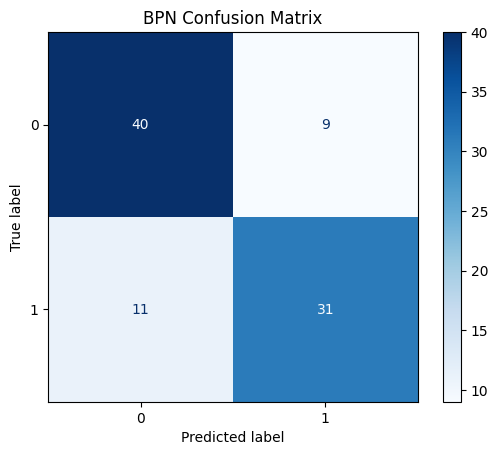

In [42]:
#creates a table comparing real labels and predicted labels.
cm_bpn = confusion_matrix(y_test, y_pred_bpn)

# creates a table comparing real labels and predicted labels.
disp_bpn = ConfusionMatrixDisplay(confusion_matrix=cm_bpn)
# draws the matrix.
disp_bpn.plot(cmap="Blues")
#adds the chart title.
plt.title("BPN Confusion Matrix")
# displays the figure.
plt.show()

40 patients without heart disease were correctly classified.

31 patients with heart disease were correctly classified.

9 patients without heart disease were incorrectly predicted as positive.

11 patients with heart disease were incorrectly predicted as negative. This is the most concerning error, where patients with heart disease were classified as not having the disease. that patient may not receive further testing or treatment on time. For this reason, reducing false negatives is very important in healthcare applications.

## 10. Loss Curve

The loss curve shows how the training error decreases during learning.

This is useful to observe whether the BPN converges properly as iterations increase.

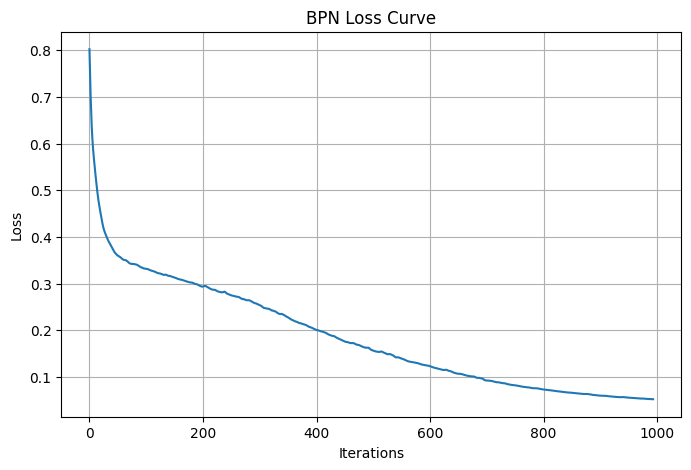

In [43]:
# creates the plotting area.
plt.figure(figsize=(8, 5))
# plots the loss value at each training iteration.
plt.plot(bpn.loss_curve_)
#adds the chart title.
plt.title("BPN Loss Curve")
#names the x-axis.
plt.xlabel("Iterations")
#names the y-axis.
plt.ylabel("Loss")
#adds grid lines.
plt.grid(True)
# displays the chart.
plt.show()

curve goes down steadily. That is a good sign. It means the model is learning and reducing its training error as iterations increase.

The curve does not jump wildly, so training seems stable.

In medical prediction, stable training increases confidence that the model is finding meaningful patterns rather than behaving randomly.

## 11. Experiment 1: Different Hidden-Layer Nodes

The lecture slides emphasize that the number of hidden-layer nodes is an important parameter.

In this experiment, different hidden-layer sizes are tested:
- 5
- 10
- 20
- 50

The purpose is to evaluate how network capacity affects training and testing accuracy. 

In [ ]:
# Define different hidden-layer node settings
hidden_nodes_list = [5, 10, 20, 50]

# Create an empty list to store results
hidden_results = []

# starts a loop, so the model is tested several times with different hidden sizes.
for nodes in hidden_nodes_list:
    
    # Create a model with the current number of hidden nodes
    model = MLPClassifier(
        hidden_layer_sizes=(nodes,),
        activation='logistic',
        learning_rate_init=0.01,
        max_iter=1000,
        tol=1e-4,
        random_state=42
    )
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Compute training accuracy
    train_acc = model.score(X_train_scaled, y_train)
    
    # Compute testing accuracy
    test_acc = model.score(X_test_scaled, y_test)
    
    # Save the results
    hidden_results.append({
        "Hidden Nodes": nodes,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc
    })

# Convert results into a DataFrame
df_hidden_results = pd.DataFrame(hidden_results)

# Show the results
df_hidden_results

,Hidden Nodes,Train Accuracy,Test Accuracy
0,5,0.929245,0.780220
1,10,0.990566,0.780220
2,20,0.877358,0.802198
3,50,0.849057,0.791209


The best testing accuracy is with 20 hidden nodes, around 0.802.

10 hidden nodes had the highest training accuracy, but not the best testing accuracy.

This means that simply increasing training accuracy does not guarantee better real performance. BUT a slightly larger hidden layer captured useful patterns better than the smaller configurations, while still generalizing reasonably well.

In a medical dataset, hidden nodes affect how much complexity the network can learn from patient variables. Too few nodes may miss important relationships, while too many may overfit. Finding a balanced structure is important so the model can detect heart disease patterns without becoming too specialized to the training data.

## 12. Plot Hidden Nodes Comparison

This plot compares training and testing accuracy for different hidden-layer node settings.

It helps identify whether increasing the number of hidden nodes improves performance or causes overfitting.

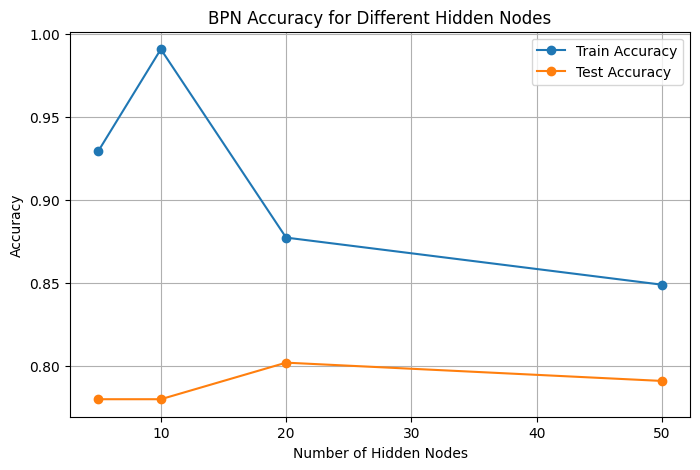

In [ ]:
# creates the figure
plt.figure(figsize=(8, 5))
# draws the training accuracy line.
plt.plot(df_hidden_results["Hidden Nodes"], df_hidden_results["Train Accuracy"], marker='o', label="Train Accuracy")
# draws the testing accuracy line.
plt.plot(df_hidden_results["Hidden Nodes"], df_hidden_results["Test Accuracy"], marker='o', label="Test Accuracy")
# add tittle
plt.title("BPN Accuracy for Different Hidden Nodes")
# label axes
plt.xlabel("Number of Hidden Nodes")
# label axes
plt.ylabel("Accuracy")
# shows which line is which.
plt.legend()
plt.grid(True)
plt.show()

The blue line shows train accuracy and the orange line shows test accuracy.

You can clearly see that 10 hidden nodes gave the highest train accuracy, but 20 hidden nodes gave the best test accuracy.

That means 20 hidden nodes is the better practical choice.

The graph confirms that the highest training accuracy does not necessarily produce the highest testing accuracy.

For a medical model, the best choice is not the one that memorizes training data. It is the one that works better on unseen patients. That is why the testing curve is more important than the training curve when choosing the final architecture.

## 13. Experiment 2: Different Learning Rates

The lecture slides also state that learning rate is a key parameter for convergence.

In this experiment, different learning rates are tested:
- 0.001
- 0.01
- 0.1

The purpose is to observe how the learning rate affects the convergence and performance of the BPN model.

In [ ]:
#defines the values to test.
learning_rates = [0.001, 0.01, 0.1]

# Create an empty list to store results
lr_results = []

# Loop through each learning rate
    # a new model is created with the current learning rate
    # the model is trained
    # train and test accuracy are measured
    # the results are stored
    # for lr in learning_rates:
    
    # Create a model with the current learning rate
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation='logistic',
        learning_rate_init=lr,
        max_iter=1000,
        tol=1e-4,
        random_state=42
    )
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Compute training accuracy
    train_acc = model.score(X_train_scaled, y_train)
    
    # Compute testing accuracy
    test_acc = model.score(X_test_scaled, y_test)
    
    # Save the results
    lr_results.append({
        "Learning Rate": lr,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc
    })

# Convert results into a DataFrame
df_lr_results = pd.DataFrame(lr_results)

# Show the results
df_lr_results

,Learning Rate,Train Accuracy,Test Accuracy
0,0.001,0.858491,0.824176
1,0.010,0.990566,0.780220
2,0.100,0.995283,0.758242


0.001: train 0.858, test 0.824

0.01: train 0.991, test 0.780

0.1: train 0.995, test 0.758

The best testing accuracy is with learning rate 0.001.

As the learning rate becomes larger, training accuracy increases, but testing accuracy decreases, which suggests poorer generalization and possible overfitting..

That suggests the larger learning rates make the model fit the training data too aggressively.

## 14. Learning Rate Comparison

This plot compares training and testing accuracy for different learning rates.

It helps identify which learning rate provides the best balance between learning speed and model performance.

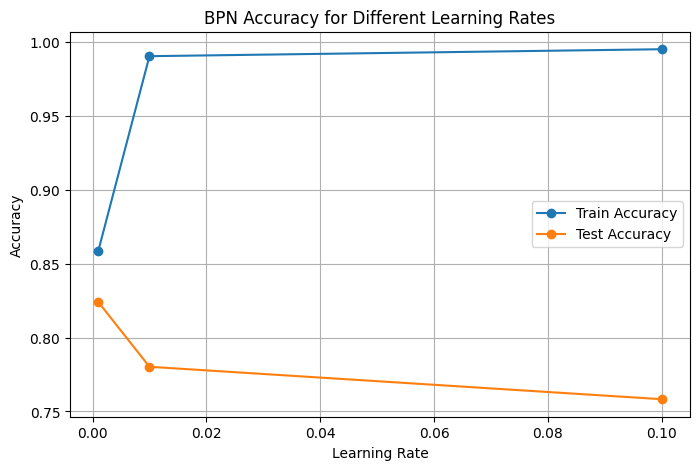

In [39]:
# Plot learning rate experiment results
plt.figure(figsize=(8, 5))
plt.plot(df_lr_results["Learning Rate"], df_lr_results["Train Accuracy"], marker='o', label="Train Accuracy")
plt.plot(df_lr_results["Learning Rate"], df_lr_results["Test Accuracy"], marker='o', label="Test Accuracy")
plt.title("BPN Accuracy for Different Learning Rates")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

This plotting block works the same way as the previous comparison graph, but now it compares different learning rates instead of hidden nodes.

The graph makes it easier to see that 0.001 was the best learning rate for test performance. This suggests that the network benefited from slower and more controlled weight updates.

f the model learns too aggressively, it may focus too much on training details and lose its ability to generalize to new patients.

## 15. Final Summary

The Backpropagation Neural Network was implemented using a feedforward neural network model with backpropagation learning.

The model was evaluated through:
- training accuracy
- testing accuracy
- classification report
- confusion matrix
- loss curve

Additional experiments were conducted to analyze:
- the effect of different hidden-layer nodes
- the effect of different learning rates

These experiments follow the discussion points highlighted in the lecture slides regarding BPN parameter selection and convergence.

## 16. Conclusion

The BPN model was able to learn and classify the Heart Disease dataset using scaled input data with acceptable performance.

but the gap between training and testing accuracy suggests overfitting.

The confusion matrix and classification report show that the model still misses some positive heart disease cases, which is important in a medical context because false negatives may delay diagnosis or treatment.

Among the tested settings, a hidden layer with 20 nodes and a learning rate of 0.001 produced better generalization, showing that careful parameter tuning improves the usefulness of the model.